# Statistical Test Advisor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/stat-test-advisor/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/stat-test-advisor/demo.ipynb)

> "Which statistical test do I use?" — describe the data, get the right test (parametric or not), and run it.

Opening **Month 12: Data Science Cookbook.** The single most common stats question isn't "what's the
p-value" - it's "which test is even correct?" Pick wrong and the p-value is meaningless. This encodes
the decision tree every stats class teaches, checks the assumptions automatically, and runs the test.

**What this notebook covers**
1. The decision tree: outcome type + #groups + pairing → test
2. Auto-checking normality to pick parametric vs non-parametric
3. Running the chosen test with scipy
4. Group distributions + result, visualized
5. All four branches on real samples


## Step 1 - The decision tree picks the test

Two independent groups of a numeric outcome → a t-test *if* the data is roughly normal, else
Mann-Whitney. The advisor runs a Shapiro-Wilk check so you don't have to eyeball a histogram.

In [1]:
from advisor import recommend, run_test, is_normal, sample_data
import numpy as np

d = sample_data()
rec = recommend("numeric_2groups", [d["group_A"], d["group_B"]])
print("Group A normal?", is_normal(d["group_A"]), "| Group B normal?", is_normal(d["group_B"]))
print("Recommended:", rec.test)
print("Reason:", rec.reason)
print("Assumptions:", rec.assumptions)


Group A normal? True | Group B normal? True
Recommended: Independent t-test
Reason: Comparing means of two independent groups (normal)
Assumptions: ['independent groups', 'normality', 'equal variance']


## Step 2 - Run it

Recommendation and execution are separate steps on purpose: you see *why* before you see the number.
Here, the two groups differ significantly.

In [2]:
res = run_test(rec, [d["group_A"], d["group_B"]])
print(f"{res.test}: statistic={res.statistic:.3f}, p={res.p_value:.4f}")
print("Effect size:", res.effect)
print(res.conclusion)


Independent t-test: statistic=-3.393, p=0.0009
Effect size: Cohen's d = -0.62
p = 0.0009 < 0.05: statistically significant - reject the null.


## Step 3 - Non-normal data flips the branch

Skewed data shouldn't use a t-test. Feed an exponential sample and the advisor switches to
Mann-Whitney automatically - same question, correct test.

In [3]:
rng = np.random.default_rng(5)
skewed_a = rng.exponential(2, 60)
skewed_b = rng.exponential(3, 60)
rec2 = recommend("numeric_2groups", [skewed_a, skewed_b])
print("Normal?", is_normal(skewed_a), "-> test:", rec2.test)
print(run_test(rec2, [skewed_a, skewed_b]).conclusion)


Normal? False -> test: Mann-Whitney U
p = 0.0002 < 0.05: statistically significant - reject the null.


## Step 4 - Visualize the comparison

The test says *whether* groups differ; the picture says *how much*. Box plots of the three groups
with the ANOVA verdict annotated.

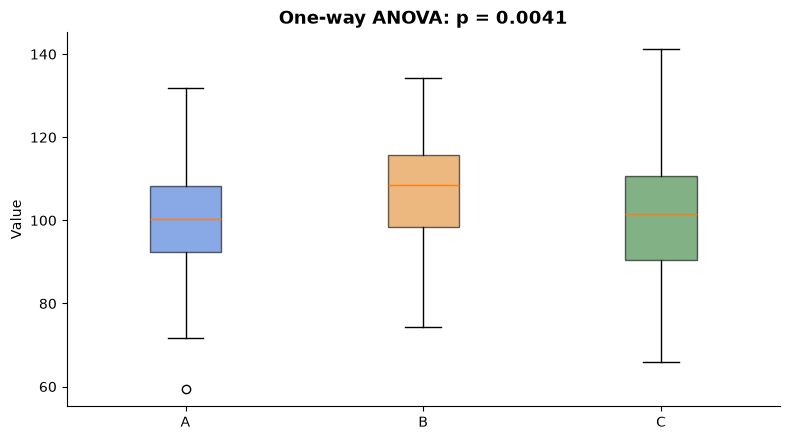

In [4]:
import matplotlib.pyplot as plt

groups = [d["group_A"], d["group_B"], d["group_C"]]
rec3 = recommend("numeric_multi", groups)
res3 = run_test(rec3, groups)

fig, ax = plt.subplots(figsize=(8, 4.5))
bp = ax.boxplot(groups, tick_labels=["A", "B", "C"], patch_artist=True)
for patch, col in zip(bp["boxes"], ["#3b6fd6", "#e08a2b", "#2e7d32"]):
    patch.set_facecolor(col)
    patch.set_alpha(0.6)
ax.set_title(f"{rec3.test}: p = {res3.p_value:.4f}", fontsize=13, weight="bold")
ax.set_ylabel("Value")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("group_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## Step 5 - Every branch, one table

The four question shapes and the test each resolves to on the sample data.

In [5]:
cases = [
    ("Means of 2 groups", "numeric_2groups", [d["group_A"], d["group_B"]], None),
    ("Means of 3+ groups", "numeric_multi", groups, None),
    ("2 categories assoc.", "categorical_2vars", [], d["contingency"]),
    ("2 numeric corr.", "correlation", [d["group_A"], d["group_C"]], None),
]
for label, kind, g, cont in cases:
    r = recommend(kind, g)
    res = run_test(r, g, contingency=cont)
    print(f"{label:<22} -> {r.test:<32} p={res.p_value:.4f}")


Means of 2 groups      -> Independent t-test               p=0.0009
Means of 3+ groups     -> One-way ANOVA                    p=0.0041
2 categories assoc.    -> Chi-square test of independence  p=0.0001
2 numeric corr.        -> Pearson correlation              p=0.4284


## Summary

| Question | Normal? | Test |
|----------|---------|------|
| 2 groups | yes / no | t-test / Mann-Whitney |
| 3+ groups | yes / no | ANOVA / Kruskal-Wallis |
| 2 categories | — | chi-square |
| 2 numeric | yes / no | Pearson / Spearman |

The advisor turns "which test?" from a half-remembered flowchart into an automatic, assumption-aware
choice - then runs it. It won't stop you asking a bad question, but it stops you answering a good one
with the wrong tool.

**Extend it:** add post-hoc tests after a significant ANOVA, Levene's test for equal variance, and a
power/sample-size calculator.

In [6]:
# --- Try your own ---
# import numpy as np
# a = np.array([...]); b = np.array([...])
# r = recommend("numeric_2groups", [a, b])
# print(r.test, "->", run_test(r, [a, b]).conclusion)


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 111,
opening **Month 12: Data Science Cookbook**.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`